L2-regularized logistic regression for binary or multiclass classification; trains a model (on `train.txt`), optimizes L2 regularization strength on `dev.txt`, and evaluates performance on `test.txt`.  Reports test accuracy with 95% confidence intervals and prints out the strongest coefficients for each class.

## Import

In [ ]:
!pip install imbalanced-learn nrclex

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 1.1 MB/s eta 0:00:00


In [ ]:
from scipy import sparse
from sklearn import linear_model
from sklearn.naive_bayes import ComplementNB
from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsRestClassifier
from collections import Counter
from imblearn.over_sampling import SMOTE
from itertools import product, combinations
import numpy as np
import operator
import nltk
import json
import math
import os
from scipy.stats import norm
import string

# Load NRC lexicon directly to avoid nrclex path resolution bug
_nrclex_path = os.path.join(os.path.dirname(__import__('nrclex').__file__), 'data', 'nrc_en.json')
with open(_nrclex_path) as f:
    NRC_LEXICON = json.load(f)

In [ ]:
nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('punkt')
!python -m nltk.downloader punkt

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


<frozen runpy>:128: RuntimeWarning: 'nltk.downloader' found in sys.modules after import of package 'nltk', but prior to execution of 'nltk.downloader'; this may result in unpredictable behaviour
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


## File Loading

In [ ]:
def load_data(filename):
    X = []
    Y = []
    with open(filename, encoding="utf-8") as file:
        next(file)
        for line in file:
            cols = line.split("\t")
            idd = cols[0]
            label = cols[1].lstrip().rstrip()
            text = cols[2].lstrip().rstrip()

            X.append(text)
            Y.append(label)

    return X, Y


## Classifier Class

In [ ]:
class Classifier:
    def __init__(self, feature_methods: list, trainX, trainY, devX, devY, testX, testY):
        self.feature_vocab = {}
        self.feature_methods = feature_methods
        self.min_feature_count=2
        self.log_reg = None

        self.trainY=trainY
        self.devY=devY
        self.testY=testY

        self.trainX = self.process(trainX, training=True)
        self.devX = self.process(devX, training=False)
        self.testX = self.process(testX, training=False)

    # Featurize entire dataset
    def featurize(self, data):
        featurized_data = []
        for text in data:
            combined_features = {}
            for feature_method in self.feature_methods:
                feats = feature_method(text)
                combined_features.update(feats)  # Merge dictionaries
            featurized_data.append(combined_features)
        return featurized_data

    # Read dataset and returned featurized representation as sparse matrix + label array
    def process(self, X_data, training = False):
        data = self.featurize(X_data)

        if training:
            fid = 0
            feature_doc_count = Counter()
            for feats in data:
                for feat in feats.keys():  # Use keys of the dictionary
                    feature_doc_count[feat] += 1

            for feat in feature_doc_count:
                if feature_doc_count[feat] >= self.min_feature_count:
                    self.feature_vocab[feat] = fid
                    fid += 1

        F = len(self.feature_vocab)
        D = len(data)
        X = sparse.dok_matrix((D, F))
        for idx, feats in enumerate(data):
            for feat, value in feats.items():  # Use key-value pairs
                if feat in self.feature_vocab:
                    X[idx, self.feature_vocab[feat]] = value

        return X

    # Train model and evaluate on held-out data
    def train(self):
        min_class_count = min(Counter(self.trainY).values())
        k_neighbors = min(5, min_class_count - 1)

        if k_neighbors >= 1:
            smote = SMOTE(k_neighbors=k_neighbors)
            trainX_resampled, trainY_resampled = smote.fit_resample(self.trainX, self.trainY)
        else:
            trainX_resampled, trainY_resampled = self.trainX, self.trainY

        C_values = [0.01, 0.1, 1, 10, 100]
        # Valid combinations: l1 only works with squared_hinge
        param_grid = [
            (C, penalty, loss)
            for C, penalty, loss in product(C_values, ['l1', 'l2'], ['hinge', 'squared_hinge'])
            if not (penalty == 'l1' and loss == 'hinge')
        ]

        best_dev_accuracy=0
        best_model=None
        for C, penalty, loss in param_grid:
            self.log_reg = OneVsRestClassifier(
                LinearSVC(C=C, penalty=penalty, loss=loss, max_iter=1000000, class_weight='balanced')
            )
            self.log_reg.fit(trainX_resampled, trainY_resampled)
            development_accuracy = self.log_reg.score(self.devX, self.devY)
            if development_accuracy > best_dev_accuracy:
                best_dev_accuracy=development_accuracy
                best_model=self.log_reg

        self.log_reg=best_model


    def test(self):
        return self.log_reg.score(self.testX, self.testY)

    def printWeights(self, n=10):
        reverse_vocab=[None]*len(self.log_reg.estimators_[0].coef_[0])
        for k in self.feature_vocab:
            reverse_vocab[self.feature_vocab[k]]=k

        for i, cat in enumerate(self.log_reg.classes_):
            weights = self.log_reg.estimators_[i].coef_[0]
            for feature, weight in list(reversed(sorted(zip(reverse_vocab, weights), key=operator.itemgetter(1))))[:n]:
                print("%s\t%.3f\t%s" % (cat, weight, feature))
            print()

## Feature Engineering

In [ ]:
X, Y = load_data("adjuticated.txt")
stopwords = set(nltk.corpus.stopwords.words('english'))
punctuation = set(string.punctuation)
punctuation.add("``")
punctuation.add("''")
punctuation.add('’')
punctuation.add('“')
punctuation.add('”')
punctuation.add('—')
punctuation.add("'s")
words_fear = {}
words_name_calling = {}
for text, label in zip(X, Y):
    if label == "Appeal to Fear":
        for word in nltk.word_tokenize(text):
            word=word.lower()
            if word not in stopwords and word not in punctuation:
                if word not in words_fear.keys():
                    words_fear[word]=0
                words_fear[word]+=1
    elif label == "Name Calling":
        for word in nltk.word_tokenize(text):
            word=word.lower()
            if word not in stopwords and word not in punctuation:
                if word not in words_name_calling.keys():
                    words_name_calling[word]=0
                words_name_calling[word]+=1

words_fear = sorted(words_fear.items(), key=operator.itemgetter(1), reverse=True)
words_name_calling = sorted(words_name_calling.items(), key=operator.itemgetter(1), reverse=True)

words_fear[:10], words_name_calling[:10]

([('act', 23),
  ('security', 22),
  ('must', 20),
  ('congress', 16),
  ('also', 15),
  ('nation', 12),
  ('national', 11),
  ('health', 11),
  ('social', 11),
  ('would', 10)],
 [('government', 11),
  ('act', 10),
  ('federal', 10),
  ('energy', 9),
  ('congress', 8),
  ('president', 8),
  ('trump', 8),
  ('funding', 8),
  ('tax', 7),
  ('would', 6)])

In [ ]:
def binary_bow_featurize(text):
    feats = {}
    words = nltk.word_tokenize(text)

    for word in words:
        word=word.lower()
        feats[word]=1

    return feats

def bigram(text):
    feats = {}
    tokens = [w.lower() for w in nltk.word_tokenize(text) if w.isalpha()]
    for i in range(len(tokens) - 1):
        feats[f"{tokens[i]}_{tokens[i+1]}"] = 1

    return feats

def trigram(text):
    feats = {}
    tokens = [w.lower() for w in nltk.word_tokenize(text) if w.isalpha()]
    for i in range(len(tokens) - 2):
        feats[f"{tokens[i]}_{tokens[i+1]}_{tokens[i+2]}"] = 1

    return feats

def appeal_to_fear_featurize(text):
    feats = {}
    words = nltk.word_tokenize(text)

    for word in words:
        word=word.lower()
        if word in ["act", "security", "must", "congress", "also", "nation", "national", "health", "social"]:
            feats[word] = feats.get(word, 0) + 1

    return feats

def name_calling_featurize(text):
    feats = {}
    words = nltk.word_tokenize(text)

    for word in words:
        word=word.lower()
        if word in ["government", "act", "federal", "energy", "congress", "president", "trump", "funding", "tax"]:
            feats[word] = feats.get(word, 0) + 1

    return feats

def nrc_featurize(text):
    counts = {}
    for word in nltk.word_tokenize(text.lower()):
        for category in NRC_LEXICON.get(word, []):
            counts[category] = counts.get(category, 0) + 1
    total = sum(counts.values()) or 1
    return {f'nrc_{cat}': count / total for cat, count in counts.items()}

In [ ]:
def confidence_intervals(accuracy, n, significance_level):
    critical_value=(1-significance_level)/2
    z_alpha=-1*norm.ppf(critical_value)
    se=math.sqrt((accuracy*(1-accuracy))/n)
    return accuracy-(se*z_alpha), accuracy+(se*z_alpha)

## Run Function

In [ ]:
def run(trainingFile, devFile, testFile):
    trainX, trainY=load_data(trainingFile)
    devX, devY=load_data(devFile)
    testX, testY=load_data(testFile)

    simple_classifier = Classifier([binary_bow_featurize], trainX, trainY, devX, devY, testX, testY)
    simple_classifier.train()
    simple_accuracy=simple_classifier.test()

    bigram_classifier = Classifier([bigram], trainX, trainY, devX, devY, testX, testY)
    bigram_classifier.train()
    bigram_accuracy=bigram_classifier.test()

    trigram_classifier = Classifier([trigram], trainX, trainY, devX, devY, testX, testY)
    trigram_classifier.train()
    trigram_accuracy=trigram_classifier.test()

    appeal_classifier = Classifier([binary_bow_featurize, bigram], trainX, trainY, devX, devY, testX, testY)
    appeal_classifier.train()
    appeal_accuracy=appeal_classifier.test()

    simple_lower, simple_upper=confidence_intervals(simple_accuracy, len(testY), .95)
    print("Test accuracy for simple binary BoW model: %.3f, 95%% CIs: [%.3f %.3f]\n" % (simple_accuracy, simple_lower, simple_upper))

    # simple_classifier.printWeights()

    bigram_lower, bigram_upper=confidence_intervals(bigram_accuracy, len(testY), .95)
    print("Test accuracy for bigram model: %.3f, 95%% CIs: [%.3f %.3f]\n" % (bigram_accuracy, bigram_lower, bigram_upper))

    # bigram_classifier.printWeights()

    trigram_lower, trigram_upper=confidence_intervals(trigram_accuracy, len(testY), .95)
    print("Test accuracy for trigram model: %.3f, 95%% CIs: [%.3f %.3f]\n" % (trigram_accuracy, trigram_lower, trigram_upper))

    appeal_lower, appeal_upper=confidence_intervals(appeal_accuracy, len(testY), .95)
    print("Test accuracy for appeal to fear model: %.3f, 95%% CIs: [%.3f %.3f]\n" % (appeal_accuracy, appeal_lower, appeal_upper))
    return {'BoW':simple_classifier, 'Bigrams':bigram_classifier, 'Trigrams': trigram_classifier, 'Appeal to fear':appeal_classifier}, testX, testY

In [ ]:
trainingFile = "train.txt"
devFile = "dev.txt"
testFile = "test.txt"
# run(trainingFile, devFile, testFile)


c.) use the model you've trained on your data to tell us something about the phenomenon you've annotated.  Potential ideas for this could include:
Does your model learn features of the phenomenon that you didn't consider in your guidelines that might cause you to rethink the category boundaries? (See Long and So 2016Links to an external site. for an example.)
What labels are often mistaken for each other? (e.g., using a confusion matrixLinks to an external site.)
What features are learned to most define the classes?  (E.g., see table 2 in Zhou and Jurgens 2020Links to an external site.).
What kind of systematic mistakes does your model make? This could involve reading through test predictions and manually categorizing mistakes that are made (see Manning 2011Links to an external site. section 3 for an example).
Are there any biases your model makes? (E.g., by performing worse on different dialects or registers of the language -- see Blodgett et al. 2016Links to an external site. for an example.)
Think about the level of balance in your dataset: Is one label extremely prevalent? How could this impact the model you developed? Is your dataset a good candidate for strategies like oversamplingLinks to an external site. or changing class weightsLinks to an external site.?
Feel free to analyze this with any model (not necessarily your best performing one) -- e.g., you may use a linear model like logistic regression for this part.  The kind of this analysis serves multiple ends -- it helps communicate what kind of information others should know about if they were to use your model in practice, and can also shed light on aspects of the fundamental concept that you hadn't considered while annotating.  You will be graded in this part on the depth of your analysis (where e.g. simply printing a confusion matrix or the top logistic regression coefficients is less complex than a full error analysis, or synthesis of multiple analyses).

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

comb_df = pd.read_csv("combined_annotations.tsv", sep='\t')
adj_df = pd.read_csv("adjuticated.txt", sep='\t')
comb_df.head()

,ID,Text,Label,annotator
0,10014,Â Safeguarding Womenâ€™s Sports: As an athlete...,Loaded Language,pd_f0
1,10014,Safeguarding Women’s Sports: As an athlete my...,Appeal to Fear,jg_f2
2,10097,57 KB) DEFENSE ACCESS ROADS III Recipient: Dep...,No Propaganda,bl_f3
3,10097,57 KB) DEFENSE ACCESS ROADS III Recipient: Dep...,Appeal to Fear,wh_f1
4,10126,""" By augmenting its marked vehicle fleet, the ...",No Propaganda,pd_f0


In [ ]:
label_count = adj_df["Label"].value_counts()
label_proportion = adj_df["Label"].value_counts(normalize = True)

pd.DataFrame({"count": label_count, "proportion": label_proportion})

,count,proportion
Label,,
No Propaganda,235,0.470
Loaded Language,176,0.352
Appeal to Fear,61,0.122
Name Calling,28,0.056


Text(0, 0.5, 'Number of labels')

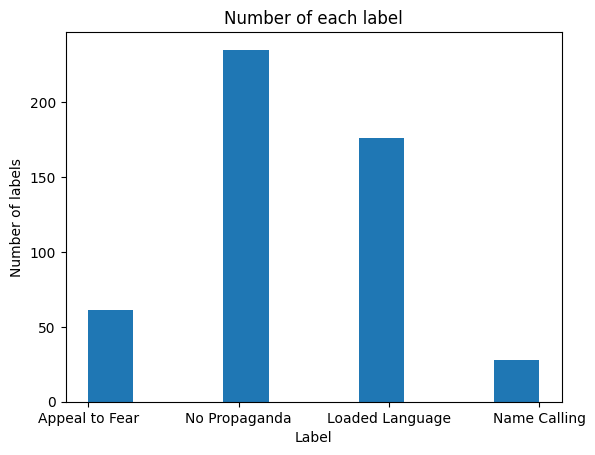

In [ ]:
plt.hist(adj_df["Label"])
plt.title("Number of each label")
plt.xlabel("Label")
plt.ylabel("Number of labels")

# **Dataset: imbalance, consistency**

There are 500 labeled datapoints in the dataset. Most data points fall under the category of No Propaganda (47%) and Loaded Language (35.2%), with a few that belong to Appeal to Fear (12.2%) and Name Calling (5.6%). This imbalance will likely cause the model to overpredict No Propaganda and Name Calling will not be learned well.
The dataset imbalance may also lead to accuracy that is misleading, as the models may perform well overall but fail on underrepresented categories.


Test accuracy for simple binary BoW model: 0.620, 95% CIs: [0.525 0.715]

Test accuracy for bigram model: 0.540, 95% CIs: [0.442 0.638]

Test accuracy for trigram model: 0.490, 95% CIs: [0.392 0.588]

Test accuracy for appeal to fear model: 0.610, 95% CIs: [0.514 0.706]



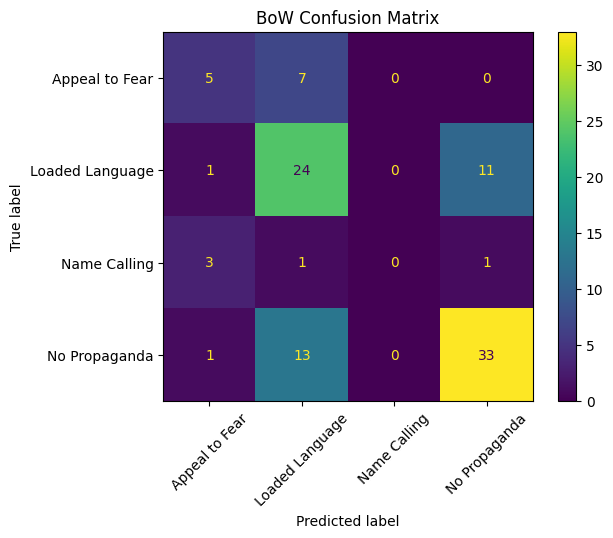

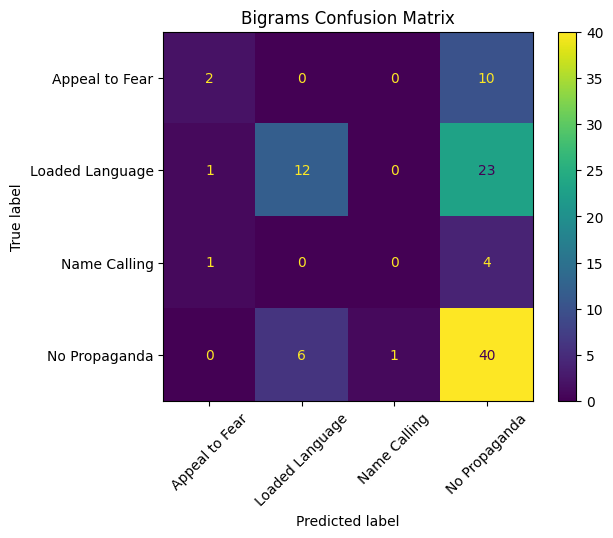

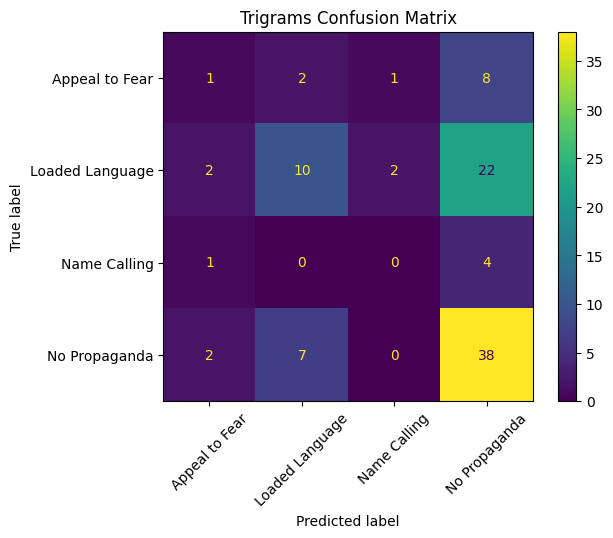

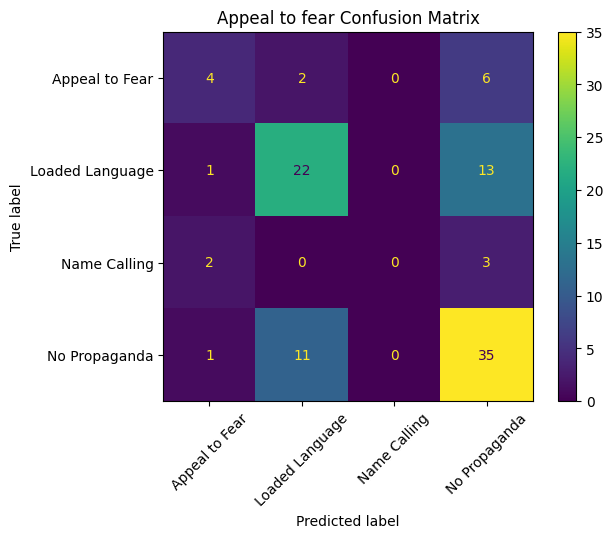

In [ ]:
from sklearn.metrics import cohen_kappa_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


models, testX, testY = run(trainingFile, devFile, testFile)
for name, clf in models.items():
  y_pred = clf.log_reg.predict(clf.testX)
  cm = confusion_matrix(testY, y_pred, labels=clf.log_reg.classes_)
  disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.log_reg.classes_)
  disp.plot(xticks_rotation=45)
  plt.title(f'{name} Confusion Matrix')


# **Model performance**
The Bag of Word model has the best performance | 0.620, 95% CIs: [0.525 0.715]
The Trigram model has the worst performance | 0.490, 95% CIs: [0.392 0.588]
The BoW model likely performs better because it can capture high frequency individual words that can generalize well across the dataset, and the n-grams (especially the tri-grams) are too sparse for the dataset size. The confidence intervals are wide and overlapping across the models which suggests that the differences in performance may not be significant, overall the model performance is moderate.


# **Confusion matrix analysis**

Appeal to Fear and Name Calling are the most frequent misclassified classes, and they are often mistaken for each other. Appeal to Fear was the most common prediction for true Name Calling cases, and Loaded Language was the most common prediction for true Appeal to Fear cases. Name Calling is never correctly predicted by any of our models, likely due to the small sample size and a lack of strong lexical cues compared to other categories.

While the majority of examples with true label Loaded Language were classified correctly, the second most common prediction was No Propaganda. The same is true vice versa. This confusion between Loaded Language and No Propaganda shows that the categories are not clearly separable based on the surface level features alone, or that more data is needed to completely learn this distinction.

Loaded Language and No Propaganda dominated the dataset and are predicted more accurately than the minority classes, which reflects the imbalanced classes. This suggests that a larger dataset, especially for underrepresented classes, may improve performance especially for the Name Calling and Appeal to Fear categories.

No Propaganda had the highest per-class accuracy, suggesting the model has an easier time distinguishing neutral tone from propaganda (binary choice) as opposed to distinguishing between propaganda types.


In [ ]:
for name, clf in models.items():
  print(f'{name} Top 10 Features')
  clf.printWeights(10)
  print("-"*20)

BoW Top 10 Features
Appeal to Fear	0.209	our
Appeal to Fear	0.198	must
Appeal to Fear	0.180	it
Appeal to Fear	0.175	spending
Appeal to Fear	0.174	congress
Appeal to Fear	0.161	i
Appeal to Fear	0.159	rising
Appeal to Fear	0.155	when
Appeal to Fear	0.151	debt
Appeal to Fear	0.151	threats

Loaded Language	0.228	continue
Loaded Language	0.204	s
Loaded Language	0.176	access
Loaded Language	0.165	’
Loaded Language	0.163	all
Loaded Language	0.162	they
Loaded Language	0.160	that
Loaded Language	0.153	make
Loaded Language	0.145	their
Loaded Language	0.142	public

Name Calling	0.223	trump
Name Calling	0.149	instead
Name Calling	0.139	president
Name Calling	0.137	government
Name Calling	0.137	congressional
Name Calling	0.135	at
Name Calling	0.133	giving
Name Calling	0.131	bureaucrats
Name Calling	0.131	out
Name Calling	0.127	waste

No Propaganda	0.207	:
No Propaganda	0.206	,
No Propaganda	0.202	h.r
No Propaganda	0.166	through
No Propaganda	0.145	act
No Propaganda	0.140	provide
No Propaganda	0.137

# **Feature analysis**

We will focus on analyzing the features learned by BoW due to its performance.
BoW Appeal to Fear key features include “must,” “debt,” and “threats,” which reflect urgency and align with the goal of invoking fear about negative outcomes. However other features “our,” “it,” and “i” are generic, which suggests that the model is partly relying on common words rather than distinctive fear based signals.

BoW Name Calling top features include “bureaucrats,” which can signal a derogatory tone but other features like “president,” “congressional”, and "government” are not inherently insulting and just related to the context. This reflects how nearly all our Name Calling data points were directed at government officials, causing the model to learn features associated with government and law makers as opposed to explicitly negative and targeted language.

BoW Loaded Language features such as “make,” “all,” and “public” are commonly used for call to action. However, BoW is also relying on generic and high frequency words like “their,” “they,” “that,” which do not form a very strong or distinct signal, likely because Loaded Language was overrepresented in the dataset and the model learned to associate regular, common parts of speech with this label.

BoW No Propaganda features are mostly punctuation tokens or policy related words that reflect a formal and neutral tone which helps the model identify neutral or informational text.


In [ ]:
for name, clf in models.items():
  y_pred = clf.log_reg.predict(clf.testX)
  if name == 'BoW':
    for text, true, pred in zip(testX, testY, y_pred):
        if true != pred:
            print("TRUE:", true)
            print("PRED:", pred)
            print(text)
            print("-"*20)

TRUE: Appeal to Fear
PRED: Loaded Language
This legislation was included in the FY2024 NDAA, which passed the House in July 2023.MONITORING ROGUE NATIONSCongress must stand firm against provocations that threaten the security of our citizens and our allies around the world. Amidst aggression from nations such as North Korea and Iran, it is imperative that America retains its ability to promote peace through strength
--------------------
TRUE: Name Calling
PRED: Appeal to Fear
Unfortunately, many of the policies of President Biden's administration such as canceling the Keystone XL pipeline, suspending new oil and gas leases on federal land and water, and green lighting the Russian Nord Stream 2 pipeline threatened America's energy security, reliability, and affordability.While President Trump has started to reverse course and promote domestic energy production, we need to continue utilizing our nation's abundance of energy resources. At the same time, we must unleash innovation in clean

# **Analyzing Errors and Biases:**

There are no clear boundaries between categories because policies can be interpreted differently. Our subjective experiences and political views may introduce ambiguity during the labeling process. This ambiguity is reflected in the model, which performed poorly especially at discriminating between kinds of propaganda.

Our adjudication process favors the label from the minority class (Name Calling, Appeal to Fear) instead of the majority class (Loaded Language, No Propaganda). However, if the two conflicting labels belong to the same minority / majority class, the final label was chosen randomly. This adjudication process was created to increase the amount of severely underrepresented minority class data. However, this also created lower quality data for the minority classes (all the datapoints “on the border” are included, diluting the strong category examples), which may have contributed to poor model performance.

We notice that the BoW model shows consistent confusion with Appeal to Fear and Loaded Language which suggests that the categories share similar rhetorical devices. To point out a misclassified example, the first prediction example was classified as Appeal to Fear by the model, which makes sense as “ threatened America's energy security” contains persuasive wording.


In [ ]:
pivot_df=comb_df.pivot_table(index='ID', columns='annotator', values='Label', aggfunc='first')
pivot_df

annotator,bl_f3,jg_f2,pd_f0,wh_f1
ID,,,,
1382,NaN,NaN,No Propaganda,Loaded Language
1414,NaN,NaN,No Propaganda,Loaded Language
1438,No Propaganda,Loaded Language,NaN,NaN
1474,NaN,NaN,Loaded Language,Appeal to Fear
1516,NaN,NaN,Loaded Language,Loaded Language
...,...,...,...,...
23694,Loaded Language,NaN,NaN,Loaded Language
23784,No Propaganda,NaN,Loaded Language,NaN
23847,NaN,Appeal to Fear,NaN,Loaded Language


In [ ]:
kappas = {}
for a1, a2 in combinations(pivot_df.columns, 2):
    sub = pivot_df[[a1, a2]].dropna()
    kappa = cohen_kappa_score(sub[a1], sub[a2])
    kappas[(a1, a2)] = kappa
    # print(sub.head())
kappas

{('bl_f3', 'jg_f2'): np.float64(0.344835736232569),
 ('bl_f3', 'pd_f0'): np.float64(0.3288409703504044),
 ('bl_f3', 'wh_f1'): np.float64(0.35450597176981546),
 ('jg_f2', 'pd_f0'): np.float64(0.31307637739418304),
 ('jg_f2', 'wh_f1'): np.float64(0.3645011600928074),
 ('pd_f0', 'wh_f1'): np.float64(0.29969284774023686)}

# **Discussion**

All models perform terribly on predicting Name Calling. Error occurred possibly because most instances of Name Calling require understanding the context and implication behind the attacks. A transformer model might be better at predicting labels that are Name Calling.

Our dataset may benefit from modifying the class weights to reduce the gradient updates on the majority class.

More data and higher quality data is needed. Our final Inter Annotator Agreement scores were relatively poor [Cohen’s Kappa: Min 0.299, Max 0.364], which suggests that our annotation guidelines may not have been sufficient. Further, we web-scraped our data and noticed multiple instances of formatting issues, which may lower the quality of the data and the model’s ability to learn meaningful patterns. Due to large class imbalance, data representing Name Calling and Appeal to Fear was very scarce, which contributed to especially poor performance on the minority classes.

The Synthetic Minority Over-Sampling Technique was employed to try and mitigate class imbalance, but it was too dramatic.
